In [145]:
import pandas as pd

data = pd.read_csv("airbnb.csv")

# PART 01

In [130]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,10,Spacious 2BR,75847,Maria,brooklyn,Greenpoint,40.59158,-73.73783,Private room,97778,5,36,4/9/2019,4.86,19,276
1,286,Cozy apartment near park,84558,Chris,staten island,St. George,40.50063,-74.09041,private room,178,1,377,14/10/2014,0.46,7,179
2,675,Cozy apartment near park,20892,Daniel,QUEENS,Elmhurst,40.88867,-74.02696,entire home/apt,72,365,99,11/8/2013,1.99,19,181
3,100,Cozy apartment near park,90224,Anna,BRONX,Fordham,40.81046,-73.86895,private room,365,1,298,3/17/2018,7.21,8,194
4,668,NaN,35757,John,QUEENS,Ridgewood,40.87452,-73.71388,entire home/apt,244,1,186,1/3/2012,2.05,20,206


In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            769 non-null    object 
 2   host_id                         1040 non-null   object 
 3   host_name                       913 non-null    object 
 4   neighbourhood_group             1040 non-null   object 
 5   neighbourhood                   1035 non-null   object 
 6   latitude                        1035 non-null   float64
 7   longitude                       1040 non-null   object 
 8   room_type                       1040 non-null   object 
 9   price                           1040 non-null   object 
 10  minimum_nights                  1040 non-null   object 
 11  number_of_reviews               1040 non-null   object 
 12  last_review                     10

In [132]:
data.shape

(1040, 16)

In [154]:
data.isnull().sum()

id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64

In [155]:
# Reason: name is a text column so replacing missing values with Unknown is appropriate.

data.name = data.name.fillna("Unknown")

data.isnull().sum()

id                                  0
name                                0
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64

In [156]:
# Reason: host name is a categorical column so the mode is used.

data.host_name = data.host_name.fillna(data.host_name.mode()[0])

data.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      5
latitude                           5
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                       13
reviews_per_month                 54
calculated_host_listings_count     1
availability_365                   0
dtype: int64

In [157]:
# Reason: neighbourhood is a categorical column so the mode is used.

data.neighbourhood = data.neighbourhood.fillna(data.neighbourhood.mode()[0])

data.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      0
latitude                           5
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                       13
reviews_per_month                 54
calculated_host_listings_count     1
availability_365                   0
dtype: int64

In [158]:
# Reason: median was used because it provides a central value and is not influenced by outliers.

data.latitude = data.latitude.fillna(data.latitude.median())

data.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                       13
reviews_per_month                 54
calculated_host_listings_count     1
availability_365                   0
dtype: int64

In [159]:
# Reason: Missing value indicates that the listing has not received any review.

data.last_review = data.last_review.fillna("No Review")

data.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                 54
calculated_host_listings_count     1
availability_365                   0
dtype: int64

In [160]:
# Reason: median was used because it provides a central value and is not influenced by outliers.

data.reviews_per_month = pd.to_numeric( data.reviews_per_month, errors="coerce" )

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            1040 non-null   object 
 2   host_id                         1040 non-null   object 
 3   host_name                       1040 non-null   object 
 4   neighbourhood_group             1040 non-null   object 
 5   neighbourhood                   1040 non-null   object 
 6   latitude                        1040 non-null   float64
 7   longitude                       1040 non-null   object 
 8   room_type                       1040 non-null   object 
 9   price                           1040 non-null   object 
 10  minimum_nights                  1040 non-null   object 
 11  number_of_reviews               1040 non-null   object 
 12  last_review                     10

In [161]:
# Reason: median was used because it provides a central value and is not influenced by outliers.

data.reviews_per_month = data.reviews_per_month.fillna(data.reviews_per_month.median())

data.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    1
availability_365                  0
dtype: int64

In [162]:
data.calculated_host_listings_count = pd.to_numeric( data.calculated_host_listings_count, errors="coerce" )

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1040 non-null   int64  
 1   name                            1040 non-null   object 
 2   host_id                         1040 non-null   object 
 3   host_name                       1040 non-null   object 
 4   neighbourhood_group             1040 non-null   object 
 5   neighbourhood                   1040 non-null   object 
 6   latitude                        1040 non-null   float64
 7   longitude                       1040 non-null   object 
 8   room_type                       1040 non-null   object 
 9   price                           1040 non-null   object 
 10  minimum_nights                  1040 non-null   object 
 11  number_of_reviews               1040 non-null   object 
 12  last_review                     10

In [163]:
# Reason: median was used because it provides a central value and is not influenced by outliers.

data.calculated_host_listings_count = data.calculated_host_listings_count.fillna( data.calculated_host_listings_count.median() )

data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

# PART 02

In [164]:
data.duplicated().sum()

np.int64(31)

In [165]:
data[data.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
81,473,Quiet private room,69506,Sofia,BRONX,Riverdale,40.62024,-73.72151,private room,$366,365,400,18/11/2015,1.41,12.0,251
276,930,Unknown,44778,Maria,Bronx,Concourse,40.81957,-73.74965,Private room,430,1,324,7/11/2013,2.90,20.0,55
278,243,Unknown,54970,Olivia,Queens,Elmhurst,40.60172,-73.76441,Entire home/apt,60,1,230,12/5/2016,5.61,4.0,131
341,263,Unknown,19141,Michael,queens,Long Island City,40.77589,-73.98962,PRIVATE ROOM,425,365,261,10/19/2019,0.95,9.0,235
409,7,Quiet private room,40117,David,Brooklyn,Greenpoint,40.61740,-74.03674,PRIVATE ROOM,358,1,369,9/25/2015,5.08,17.0,54
442,645,Modern studio,74864,James,Staten Island,Tompkinsville,40.68015,-73.99683,Shared room,257,3,304,3/5/2011,2.89,12.0,113
457,719,Cozy apartment near park,50809,Sofia,staten island,St. George,40.76376,-73.96683,Shared room,418,1,66,12/19/2011,3.03,13.0,102
480,508,Unknown,13050,David,brooklyn,Greenpoint,40.85039,-73.87834,Private room,60524,3,292,5/23/2019,4.24,17.0,80
515,703,Unknown,55511,Michael,Staten Island,Tompkinsville,40.59847,-73.83259,PRIVATE ROOM,$109,7,348,4/21/2015,9.14,14.0,209
567,109,Unknown,60634,Michael,Brooklyn,Bushwick,40.85512,-73.79206,Private room,287,1,327,6/20/2015,2.20,20.0,68


In [166]:
data = data.drop_duplicates()

In [167]:
data.duplicated().sum()

np.int64(0)

# PART 03

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1009 non-null   object 
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   object 
 8   room_type                       1009 non-null   object 
 9   price                           1009 non-null   object 
 10  minimum_nights                  1009 non-null   object 
 11  number_of_reviews               1009 non-null   object 
 12  last_review                     1009 no

In [209]:
data.host_id = pd.to_numeric(data.host_id, errors="coerce")

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1009 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           1009 non-null   float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1009 non-null   float64
 12  last_review                     1009 no

In [210]:
data.longitude = pd.to_numeric(data.longitude, errors="coerce")

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1009 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           1009 non-null   float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1009 non-null   float64
 12  last_review                     1009 no

In [211]:
data.price = pd.to_numeric(data.price, errors="coerce")

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1009 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1009 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           1009 non-null   float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1009 non-null   float64
 12  last_review                     1009 no

In [212]:
data.minimum_nights = pd.to_numeric(data.minimum_nights, errors="coerce")

In [213]:
data.number_of_reviews = pd.to_numeric(data.number_of_reviews, errors="coerce")

In [214]:
data.reviews_per_month = pd.to_numeric(data.reviews_per_month, errors="coerce")

In [215]:
data.calculated_host_listings_count = pd.to_numeric(data.calculated_host_listings_count, errors="coerce")

In [178]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1006 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1007 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           852 non-null    float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1007 non-null   float64
 12  last_review                     1009 no

In [216]:
data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    5
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [179]:
numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

C:\Users\Zohaib Ali\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:128: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[self.orient] = ""
C:\Users\Zohaib Ali\AppData\Roaming\Python\Python314\site-packages\

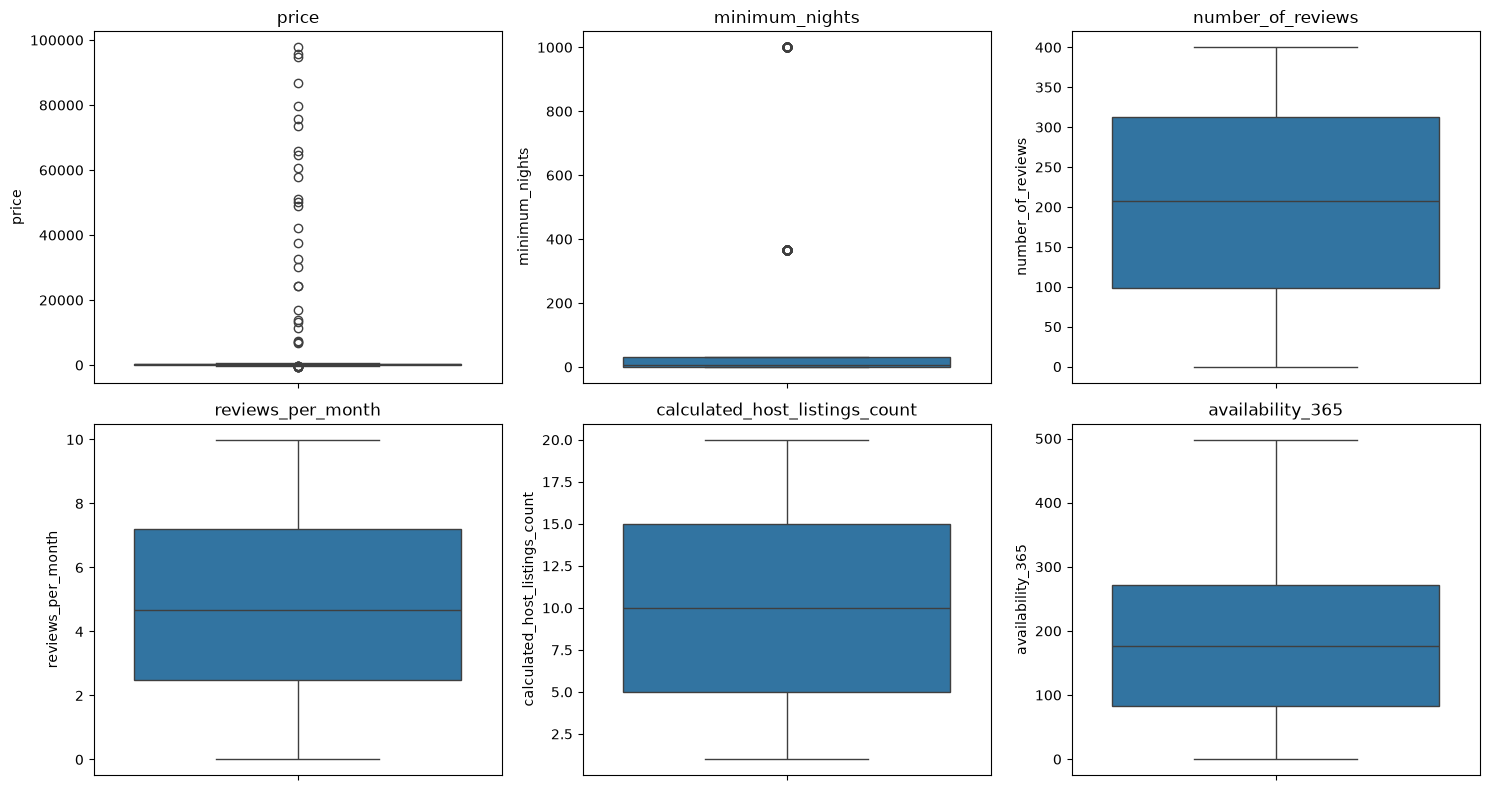

In [180]:
plt.figure(figsize=(15,8))

for i, column in enumerate(numeric_columns, 1):

    plt.subplot(2,3,i)
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [181]:
for column in numeric_columns:

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) | (data[column] > upper_limit)
    ]

    print(f"{column} Outliers")

    outliers

    print("Total Outliers:", outliers.shape[0])

    print("-"*50)

price Outliers
Total Outliers: 37
--------------------------------------------------
minimum_nights Outliers
Total Outliers: 199
--------------------------------------------------
number_of_reviews Outliers
Total Outliers: 0
--------------------------------------------------
reviews_per_month Outliers
Total Outliers: 0
--------------------------------------------------
calculated_host_listings_count Outliers
Total Outliers: 0
--------------------------------------------------
availability_365 Outliers
Total Outliers: 0
--------------------------------------------------


In [182]:
for column in numeric_columns:

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    data[column] = data[column].clip(lower_limit, upper_limit)

C:\Users\Zohaib Ali\AppData\Local\Temp\ipykernel_6388\4146520366.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[column] = data[column].clip(lower_limit, upper_limit)
C:\Users\Zohaib Ali\AppData\Local\Temp\ipykernel_6388\4146520366

C:\Users\Zohaib Ali\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:128: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[self.orient] = ""
C:\Users\Zohaib Ali\AppData\Roaming\Python\Python314\site-packages\

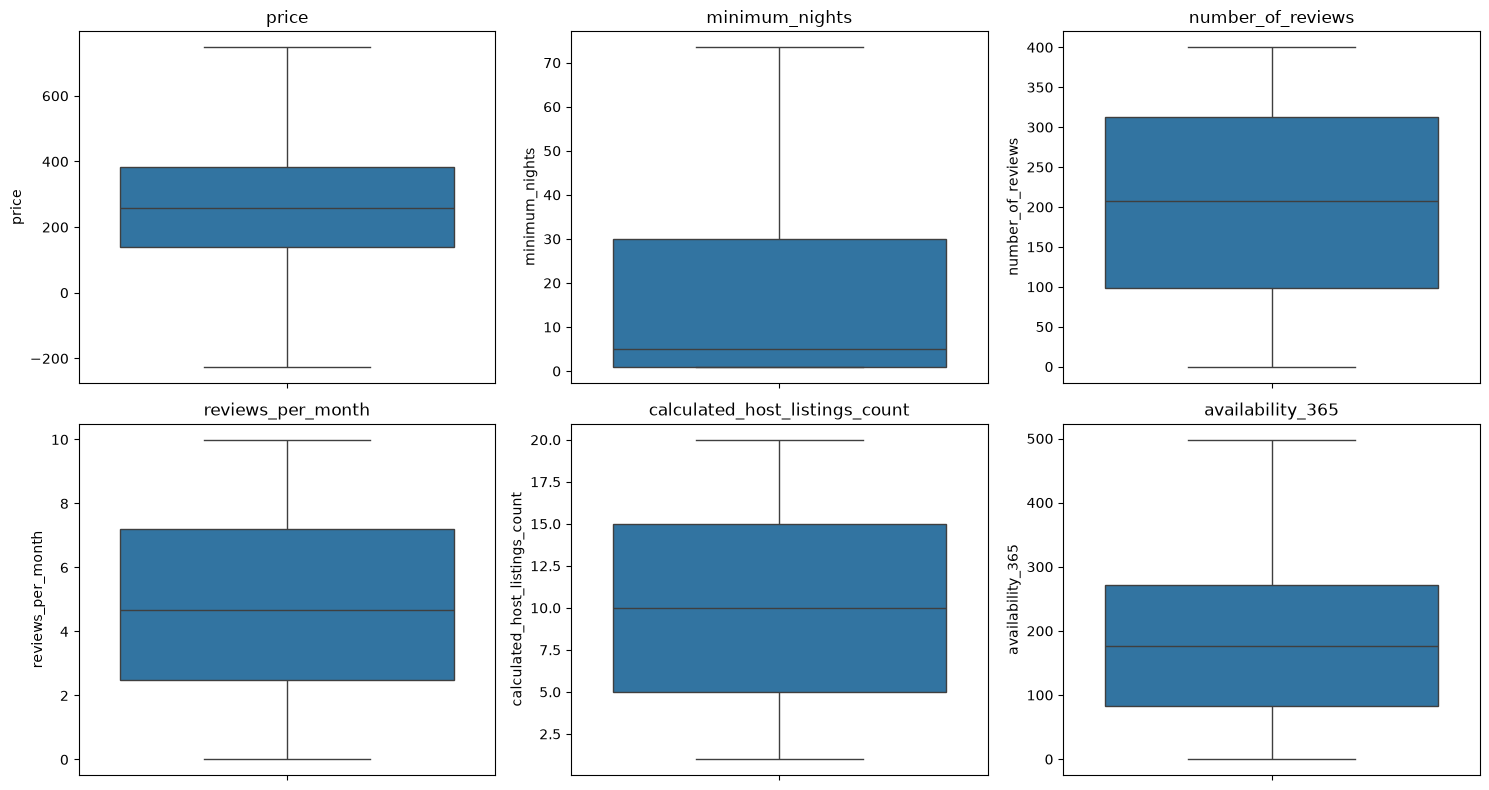

In [183]:
plt.figure(figsize=(15,8))

for i, column in enumerate(numeric_columns, 1):

    plt.subplot(2,3,i)
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout()
plt.show()

# PART 04

All columns such as price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365, host_id, id, latitude, and longitude were originally stored as object (text). These columns were converted to numeric data types using pd.to_numeric() before performing outlier detection and visualization. This conversion was necessary because statistical operations such as IQR calculation and boxplots require numeric data.

In [184]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1006 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1007 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           852 non-null    float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1007 non-null   float64
 12  last_review                     1009 no

# PART 05

No additional conversion was required because the necessary numeric columns had already been converted in Part 3 which enabled outlier detection and visualization.

In [185]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1006 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1007 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           852 non-null    float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1007 non-null   float64
 12  last_review                     1009 no

# PART 06

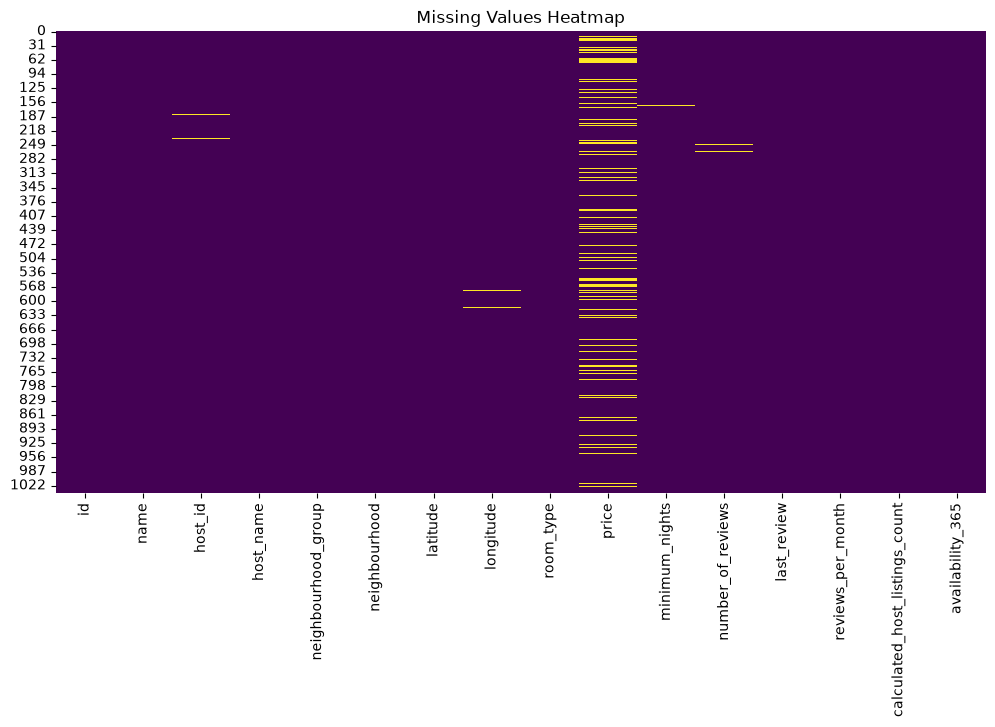

In [186]:
plt.figure(figsize=(12,6))

sns.heatmap(data.isnull(), cmap="viridis", cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

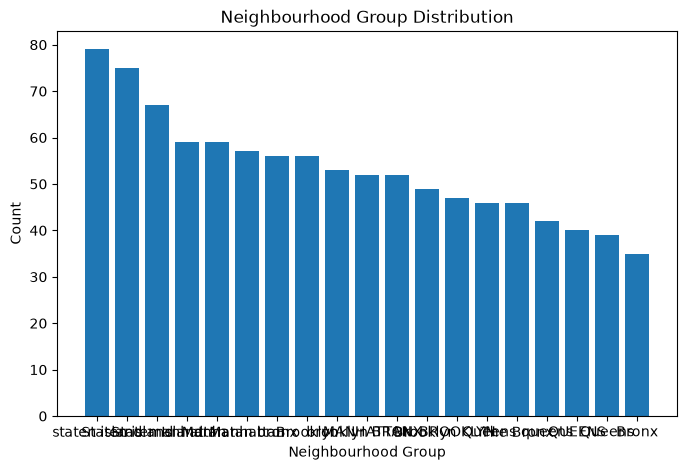

In [187]:
count = data.neighbourhood_group.value_counts()

plt.figure(figsize=(8,5))

plt.bar(x=count.index, height=count.values)

plt.title("Neighbourhood Group Distribution")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")

plt.show()

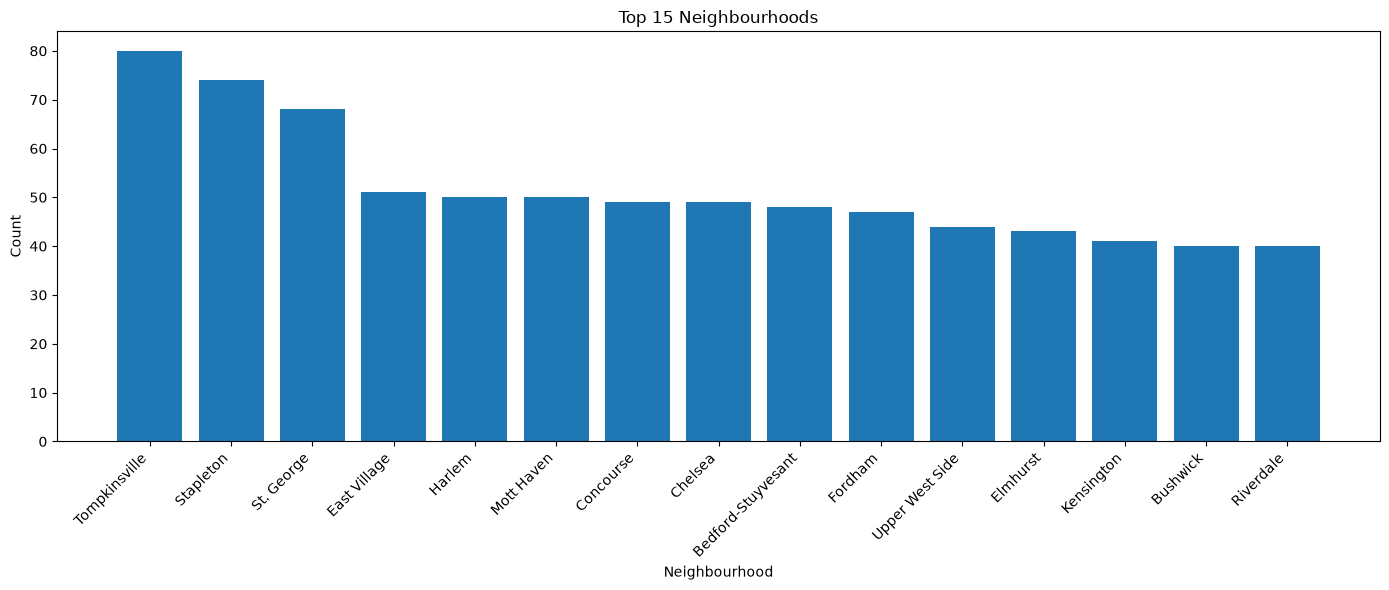

In [188]:
count = data.neighbourhood.value_counts().head(15)

plt.figure(figsize=(14,6))

plt.bar(x=count.index, height=count.values)

plt.title("Top 15 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

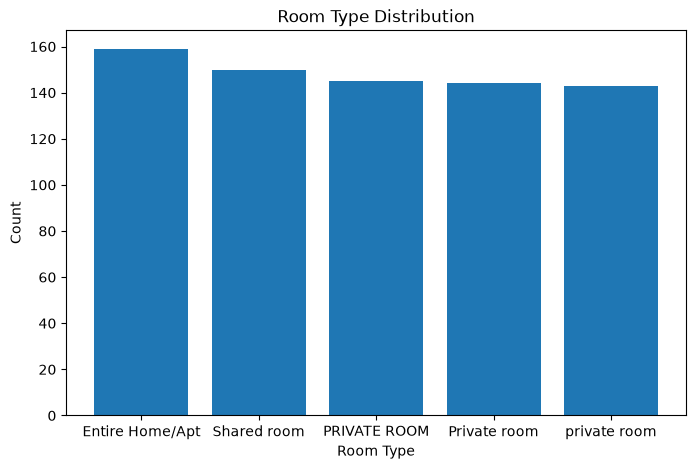

In [189]:
count = data.room_type.value_counts().head()

plt.figure(figsize=(8,5))

plt.bar(x=count.index, height=count.values)

plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")

plt.show()

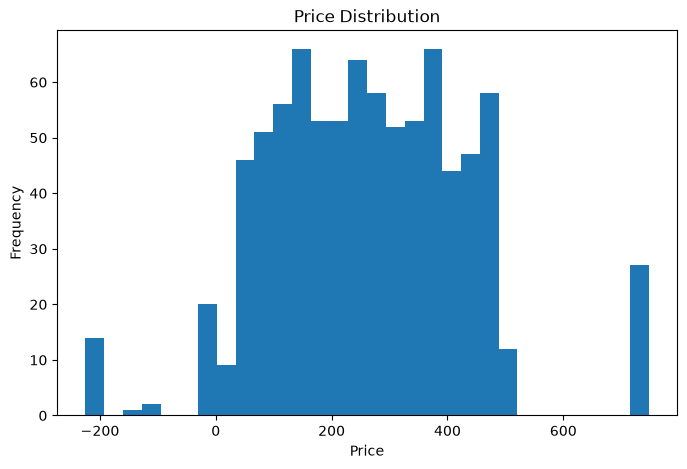

In [190]:
plt.figure(figsize=(8,5))

plt.hist(data.price, bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

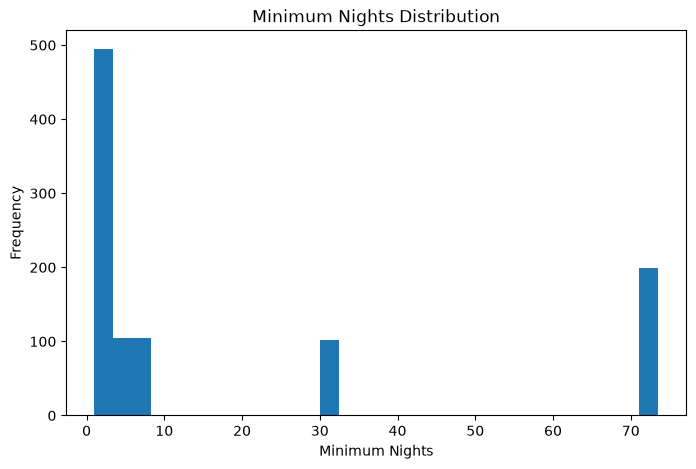

In [191]:
plt.figure(figsize=(8,5))

plt.hist(data.minimum_nights, bins=30)

plt.title("Minimum Nights Distribution")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")

plt.show()

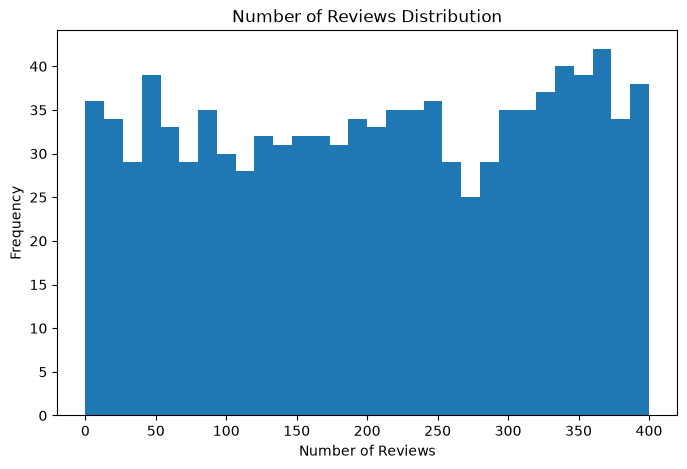

In [192]:
plt.figure(figsize=(8,5))

plt.hist(data.number_of_reviews, bins=30)

plt.title("Number of Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")

plt.show()

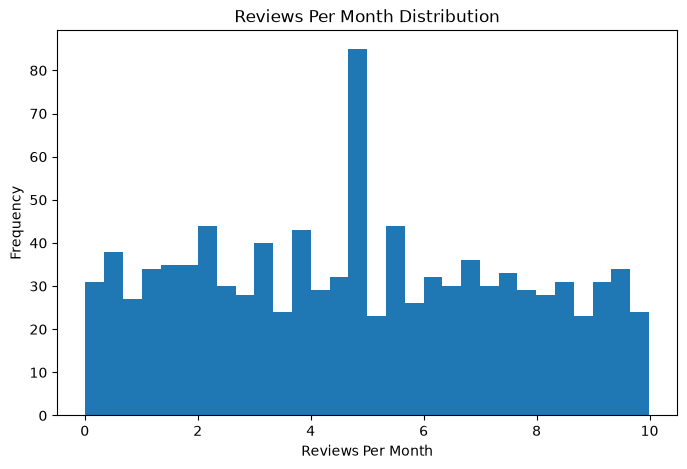

In [193]:
plt.figure(figsize=(8,5))

plt.hist(data.reviews_per_month, bins=30)

plt.title("Reviews Per Month Distribution")
plt.xlabel("Reviews Per Month")
plt.ylabel("Frequency")

plt.show()

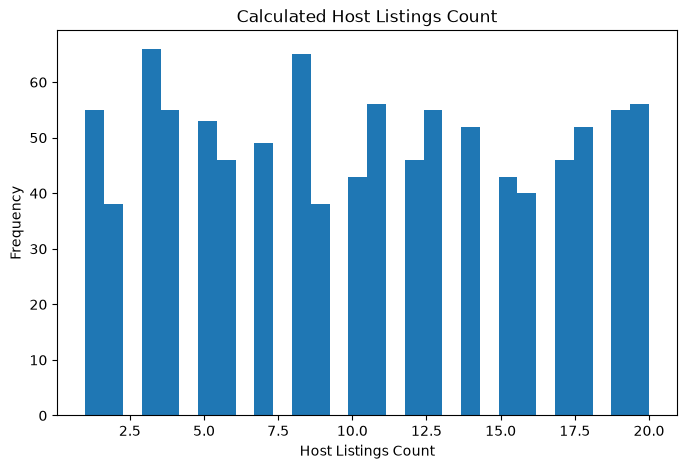

In [194]:
plt.figure(figsize=(8,5))

plt.hist(data.calculated_host_listings_count, bins=30)

plt.title("Calculated Host Listings Count")
plt.xlabel("Host Listings Count")
plt.ylabel("Frequency")

plt.show()

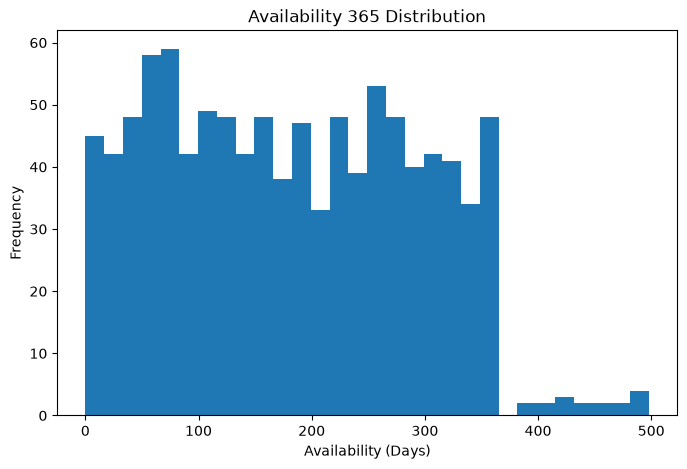

In [195]:
plt.figure(figsize=(8,5))

plt.hist(data.availability_365, bins=30)

plt.title("Availability 365 Distribution")
plt.xlabel("Availability (Days)")
plt.ylabel("Frequency")

plt.show()

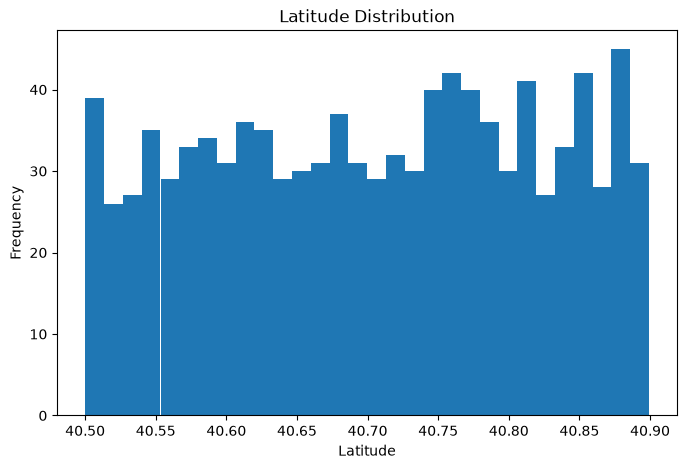

In [196]:
plt.figure(figsize=(8,5))

plt.hist(data.latitude, bins=30)

plt.title("Latitude Distribution")
plt.xlabel("Latitude")
plt.ylabel("Frequency")

plt.show()

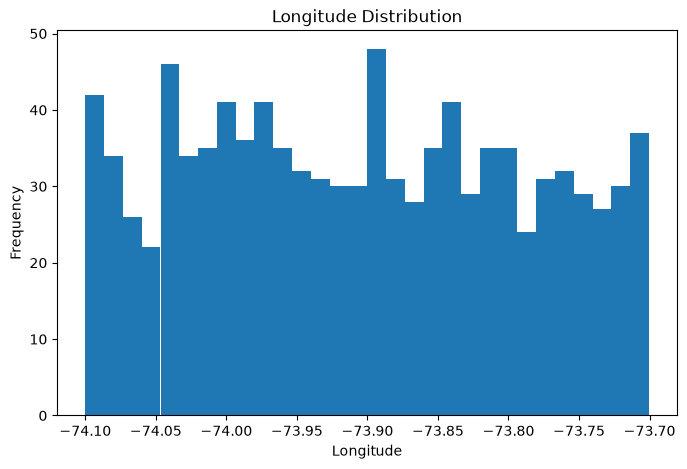

In [197]:
plt.figure(figsize=(8,5))

plt.hist(data.longitude, bins=30)

plt.title("Longitude Distribution")
plt.xlabel("Longitude")
plt.ylabel("Frequency")

plt.show()

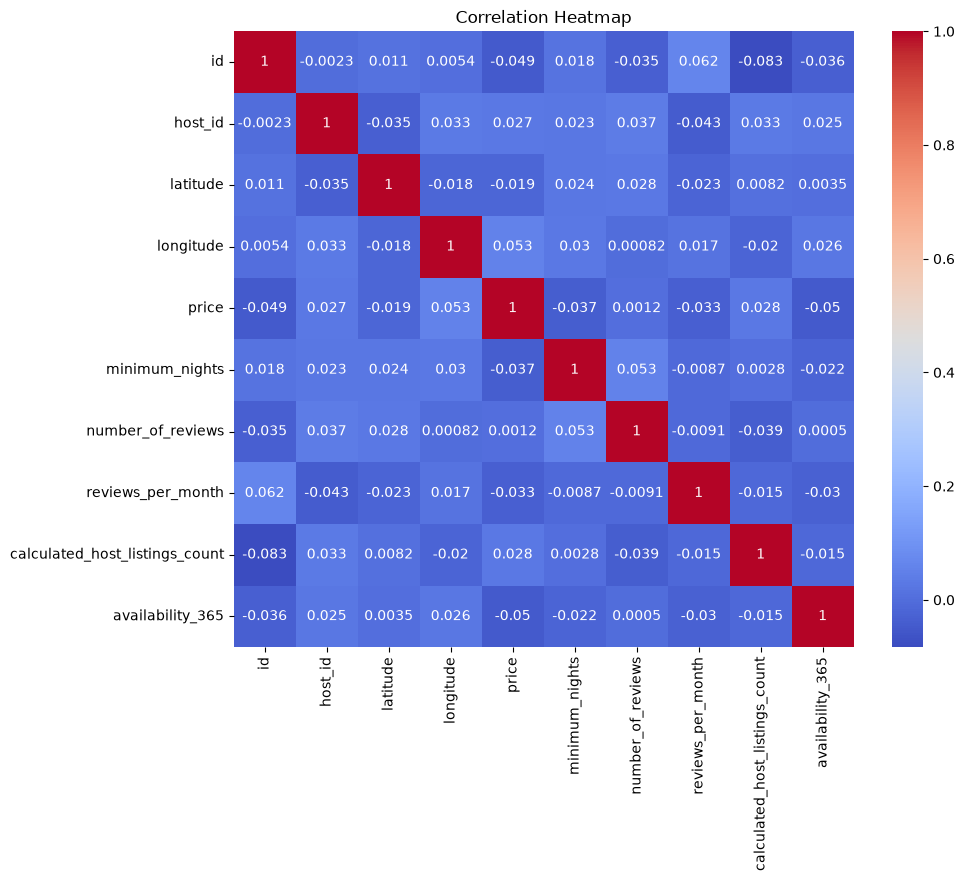

In [198]:
numeric_data = data.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# PART 07

In [199]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1009 entries, 0 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1009 non-null   int64  
 1   name                            1009 non-null   object 
 2   host_id                         1006 non-null   float64
 3   host_name                       1009 non-null   object 
 4   neighbourhood_group             1009 non-null   object 
 5   neighbourhood                   1009 non-null   object 
 6   latitude                        1009 non-null   float64
 7   longitude                       1007 non-null   float64
 8   room_type                       1009 non-null   object 
 9   price                           852 non-null    float64
 10  minimum_nights                  1004 non-null   float64
 11  number_of_reviews               1007 non-null   float64
 12  last_review                     1009 no

In [200]:
data.isnull().sum()

id                                  0
name                                0
host_id                             3
host_name                           0
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           2
room_type                           0
price                             157
minimum_nights                      5
number_of_reviews                   2
last_review                         0
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

In [208]:
data.host_id = pd.to_numeric(data.host_id, errors="coerce")

data.host_id = data.host_id.fillna(data.host_id.median())

data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    5
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [ ]:
data.longitude = pd.to_numeric(data.longitude, errors="coerce")

data.longitude = data.longitude.fillna(data.longitude.median())

In [ ]:

data.price = pd.to_numeric(data.price, errors="coerce")

data.price = data.price.fillna(data.price.median())

In [218]:
data.number_of_reviews = pd.to_numeric(data.number_of_reviews, errors="coerce")

data.number_of_reviews = data.number_of_reviews.fillna(data.number_of_reviews.median())

In [221]:
data.minimum_nights = pd.to_numeric(data.minimum_nights, errors="coerce")

data.minimum_nights = data.minimum_nights.fillna(data.minimum_nights.median())

In [206]:
data.calculated_host_listings_count = pd.to_numeric(data.calculated_host_listings_count,errors="coerce")

data.calculated_host_listings_count = data.calculated_host_listings_count.fillna(data.calculated_host_listings_count.median())

In [222]:
data.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64